## Random Walk Generation

$$ \frac{S_{t+dt}-S_t}{S_t} = \mu dt + \sigma\sqrt{dt}\xi_t $$

In [1]:
import numpy as np
import pandas as pd

In [2]:
def gbm0(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100.0):
    """
    Evolution of a Stock Price using a Geometric Brownian Motion Model
    """
    dt = 1 / steps_per_year
    n_steps = int(n_years * steps_per_year)
    xi = np.random.normal(size = (n_steps, n_scenarios))
    rets = mu * dt + sigma * np.sqrt(dt) * xi
    rets = pd.DataFrame(rets)
    prices = s_0 * (1 + rets).cumprod()
    return prices

In [3]:
p = gbm0(10, n_scenarios = 3)
p.head()

,0,1,2
0,105.484320,97.777171,99.782114
1,98.985879,96.660021,99.510735
2,100.516282,94.336570,97.027317
3,106.383393,93.191945,101.581785
4,99.848754,96.344761,106.081409


In [4]:
p.shape

(120, 3)

<Axes: >

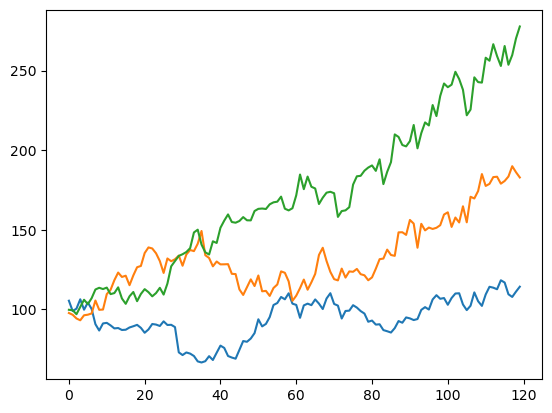

In [5]:
p.plot(legend = False)

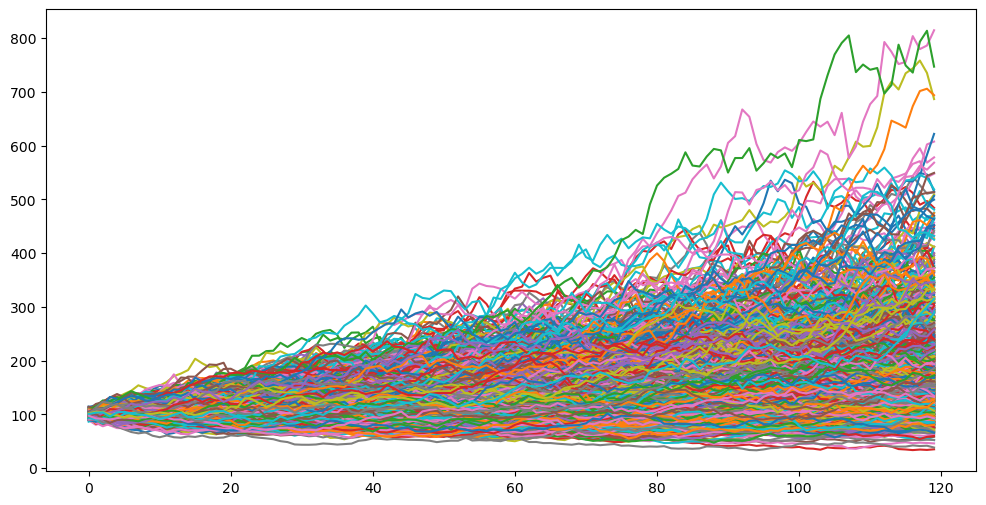

In [6]:
p = gbm0(n_years = 10, n_scenarios = 1000).plot(figsize = (12, 6), legend = False)

In [14]:
def gbm(n_years = 10, n_scenarios = 1000, mu = 0.07, sigma = 0.15, steps_per_year = 12, s_0 = 100.0):
    """
    Evolution of a Stock Price using a Geometric Brownian Motion Model
    """
    dt = 1 / steps_per_year
    n_steps = int(n_years * steps_per_year)
    rets_plus_1 = np.random.normal(loc = 1 + mu * dt, scale = sigma * np.sqrt(dt), size = (n_steps, n_scenarios))
    rets_plus_1[0] = 1
    prices = s_0 * pd.DataFrame(rets_plus_1).cumprod()
    return prices

In [8]:
%timeit gbm0(n_years = 5, n_scenarios = 1000)

1.26 ms ± 1.66 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [9]:
%timeit gbm(n_years = 5, n_scenarios = 1000)

1.18 ms ± 1.72 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


<Axes: >

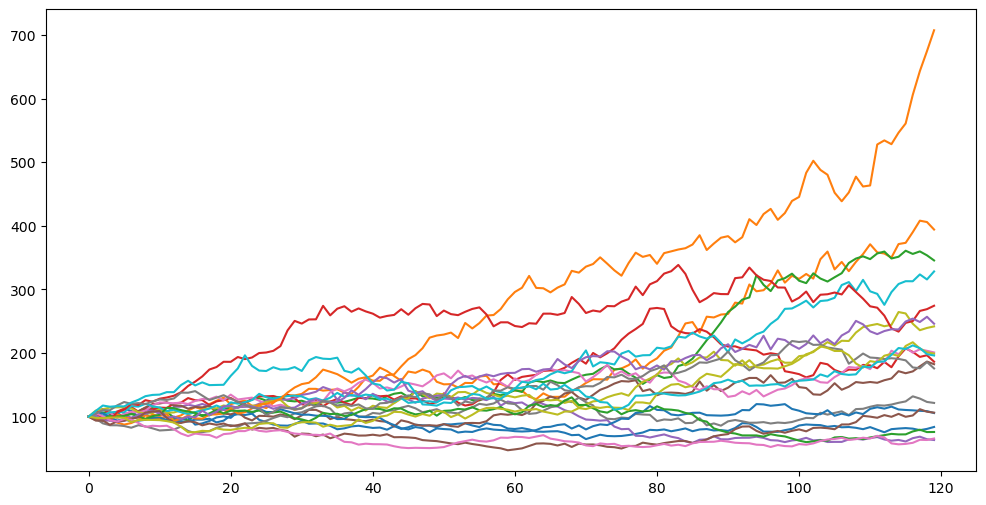

In [15]:
gbm(n_years = 10, n_scenarios = 20).plot(legend = False, figsize = (12, 6))

In [16]:
gbm(n_scenarios = 10).head()

,0,1,2,3,4,5,6,7,8,9
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,102.466653,93.719551,96.482161,102.527492,105.265347,101.278002,107.568062,96.139748,94.835441,106.366724
2,102.271745,92.081343,99.313586,96.830054,107.843066,103.477717,109.250397,95.660376,100.896140,112.665051
3,106.909496,84.250530,99.901485,105.121701,114.479008,107.748899,104.244211,97.750207,104.456102,118.029207
4,110.955774,78.987101,97.050387,108.611019,119.895066,114.589103,102.928828,104.565187,102.104014,125.078221
